In [1]:
using LinearAlgebra
using Plots
using Printf
gr()

Plots.GRBackend()

In [2]:
function rosenbrock(x)
    return (1.0 - x[1])^2 + 100.0 * (x[2] - x[1]^2)^2
end

function rastrigin(x)
    return 20.0 + x[1]^2 - 10.0*cos(2*pi*x[1]) + x[2]^2 - 10.0*cos(2*pi*x[2])
end

function schwefel(x)
    return 418.9829*2 - (x[1]*sin(sqrt(abs(x[1]))) + x[2]*sin(sqrt(abs(x[2]))))
end

schwefel (generic function with 1 method)

In [3]:
function get_gradient(f, x; h=1e-6)
    n = length(x)
    grad = zeros(n)
    for i in 1:n
        x_plus = copy(x); x_plus[i] += h
        x_minus = copy(x); x_minus[i] -= h
        grad[i] = (f(x_plus) - f(x_minus)) / (2*h)
    end
    return grad
end

get_gradient (generic function with 1 method)

In [4]:
function newton_1d(g, alpha0=0.0; tol=1e-5, max_iter=30, h=1e-5, max_alpha=10.0)
    alpha = alpha0
    for iter in 1:max_iter
        if !isfinite(alpha) || abs(alpha) > max_alpha
            return 0.0
        end
        
        try
            df = (g(alpha + h) - g(alpha - h)) / (2 * h)
            d2f = (g(alpha + h) - 2 * g(alpha) + g(alpha - h)) / (h^2)
            
            if !isfinite(df) || !isfinite(d2f)
                return alpha
            end
            
            if abs(d2f) < 1e-8 
                break 
            end
            
            step = df / d2f
            if !isfinite(step)
                break
            end
            
            alpha_new = alpha - step
            
            # Ограничение на шаг
            if abs(alpha_new) > max_alpha
                alpha_new = sign(alpha_new) * max_alpha
            end
            
            alpha = alpha_new
            
            if abs(step) < tol || abs(df) < tol 
                break 
            end
        catch
            break
        end
    end
    
    if !isfinite(alpha) || abs(alpha) > max_alpha
        return 0.0
    end
    
    return alpha
end


newton_1d (generic function with 2 methods)

In [5]:
function dfp(f, x0; max_iters=100, epsilon=1e-4)
    x = copy(x0)
    trajectory = [copy(x)]
    n = length(x)
    
    H = Matrix{Float64}(I, n, n)
    grad = get_gradient(f, x)
    
    for i in 1:max_iters
        if norm(grad) < epsilon 
            break 
        end
        
        p = -H * grad
        
        if !all(isfinite, p)
            println("Предупреждение: невалидное направление на итерации $i")
            H = Matrix{Float64}(I, n, n)
            p = -grad
        end
        
        g(alpha) = f(x + alpha * p)
        alpha = newton_1d(g, 0.0)
        
        if !isfinite(alpha) || abs(alpha) < 1e-10
            alpha = 1e-6
        end
        
        x_new = x + alpha * p
        grad_new = get_gradient(f, x_new)
        
        delta_x = x_new - x
        delta_g = grad_new - grad
        
        dot_dx_dg = dot(delta_x, delta_g)
        if abs(dot_dx_dg) > 1e-10 && dot_dx_dg > 0
            A = (delta_x * delta_x') / dot_dx_dg
            
            z = H * delta_g
            dot_z_dg = dot(delta_g, z)
            
            if abs(dot_z_dg) > 1e-10
                B = (H * delta_g) * (delta_g' * H) / dot_z_dg
                H = H + A - B
            else
                H = H + A
            end
        end
        
        if all(isfinite, x_new) && all(isfinite, grad_new)
            x = x_new
            grad = grad_new
            push!(trajectory, copy(x))
        else
            println("Предупреждение: получена невалидная точка на итерации $i")
            break
        end
        
        try
            eigenvals = eigvals(H)
            if minimum(eigenvals) <= 0
                println("Предупреждение: Матрица H не положительно определена на итерации $i")
                H = Matrix{Float64}(I, n, n)
            end
        catch
            H = Matrix{Float64}(I, n, n)
        end
    end
    
    return x, trajectory
end


dfp (generic function with 1 method)

In [6]:
function visualize_all_methods(f, name, x0, bounds_pad=2.0)
    println("ФУНКЦИЯ: $name | Старт: $x0")
    
    t1 = time()
    x_dfp, hist_dfp = dfp(f, x0)
    time_dfp = round(time() - t1, digits=6)
    iters1 = length(hist_dfp) - 1
    
    println("\nDFP (Дэвидон-Флэтчер-Пауэл):")
    println("Итераций = $iters1 | Минимум = $(round.(x_dfp, digits=6)) | f(x) = $(round(f(x_dfp), digits=10)) | Время = $time_dfp сек")
    
    all_points = vcat(hist_dfp)
    all_x = [p[1] for p in all_points]
    all_y = [p[2] for p in all_points]
    
    valid_indices = [i for i in 1:length(all_x) if isfinite(all_x[i]) && isfinite(all_y[i])]
    all_x = [all_x[i] for i in valid_indices]
    all_y = [all_y[i] for i in valid_indices]
    
    if isempty(all_x) || isempty(all_y)
        println("Ошибка: все точки содержат NaN или Inf")
        return x_dfp
    end
    
    min_x = minimum(all_x) - bounds_pad
    max_x = maximum(all_x) + bounds_pad
    min_y = minimum(all_y) - bounds_pad
    max_y = maximum(all_y) + bounds_pad
    
    if !isfinite(min_x) || !isfinite(max_x) || !isfinite(min_y) || !isfinite(max_y)
        println("Ошибка: диапазоны для визуализации содержат NaN или Inf")
        return x_dfp
    end
    
    xr = range(min_x, max_x, length=100)
    yr = range(min_y, max_y, length=100)
    Z = [f([x, y]) for y in yr, x in xr]
    
    Z = [isfinite(z) ? z : 1e10 for z in Z]
    
    p1 = contour(xr, yr, Z, levels=50, color=:grays, fill=false, title="$name (2D)", xlabel="x1", ylabel="x2")
    
    hist_x_dfp = [p[1] for p in hist_dfp if isfinite(p[1]) && isfinite(p[2])]
    hist_y_dfp = [p[2] for p in hist_dfp if isfinite(p[1]) && isfinite(p[2])]
    
    if !isempty(hist_x_dfp) && !isempty(hist_y_dfp)
        plot!(p1, hist_x_dfp, hist_y_dfp, color=:blue, lw=2, marker=:circle, markersize=3, label="DFP")
        scatter!(p1, [x_dfp[1]], [x_dfp[2]], color=:red, markersize=2, marker=:diamond, label="DFP")
    end
    
    p2 = surface(xr, yr, Z, color=:grays, alpha=0.5, colorbar=false, title="3D", xlabel="x1", ylabel="x2", zlabel="f(x)")
    
    if !isempty(hist_x_dfp) && !isempty(hist_y_dfp)
        z_vals_dfp = [f([hist_x_dfp[i], hist_y_dfp[i]]) for i in 1:length(hist_x_dfp)]
        z_vals_dfp = [isfinite(z) ? z : 1e10 for z in z_vals_dfp]
        plot!(p2, hist_x_dfp, hist_y_dfp, z_vals_dfp, color=:blue, lw=3, label="DFP")
        scatter!(p2, [x0[1]], [x0[2]], [f(x0)], color=:red, markersize=2, marker=:diamond, label="")
    end
    
    display(plot(p1, p2, layout=(1,2), size=(1400, 600)))
    
    return x_dfp
end

visualize_all_methods (generic function with 2 methods)

ФУНКЦИЯ: Розенброк | Старт: [-1.2, 1.0]

DFP (Дэвидон-Флэтчер-Пауэл):
Итераций = 23 | Минимум = [0.999997, 0.999995] | f(x) = 0.0 | Время = 1.193 сек


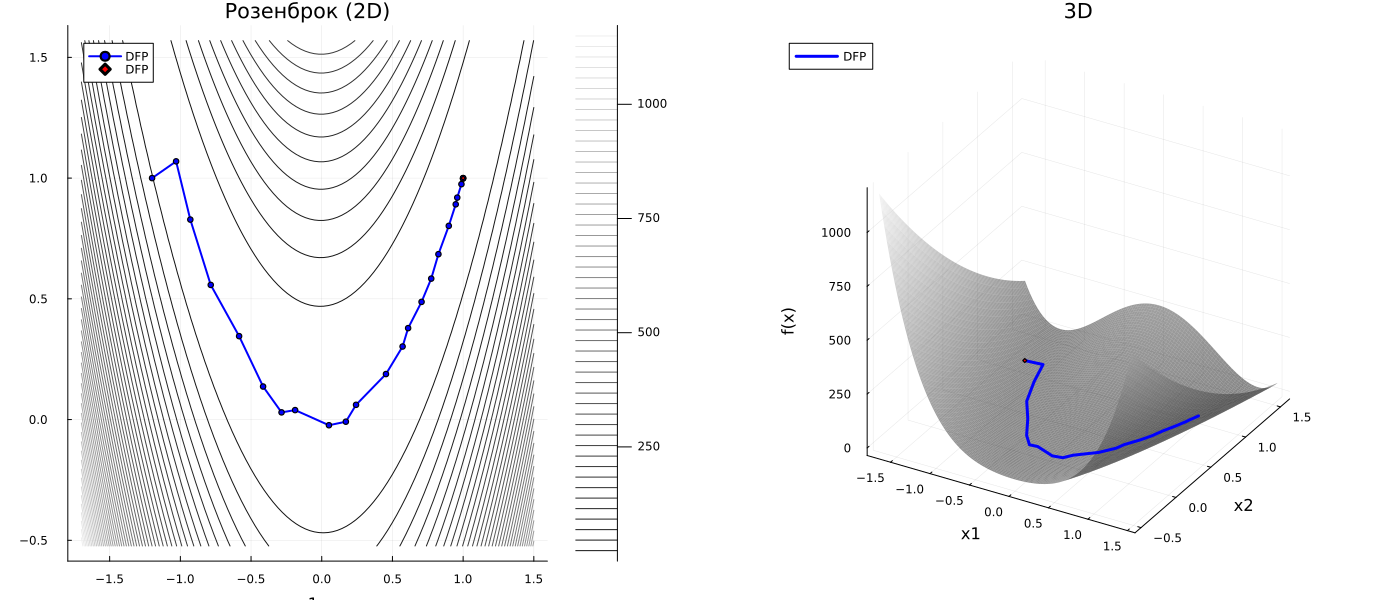

2-element Vector{Float64}:
 0.9999973213244336
 0.9999948201656903

In [7]:
visualize_all_methods(rosenbrock, "Розенброк", [-1.2, 1.0], 0.5)

ФУНКЦИЯ: Растригин | Старт: [1.2, 1.5]

DFP (Дэвидон-Флэтчер-Пауэл):
Итераций = 40 | Минимум = [1.507641, 1.507641] | f(x) = 44.5229177696 | Время = 0.026 сек


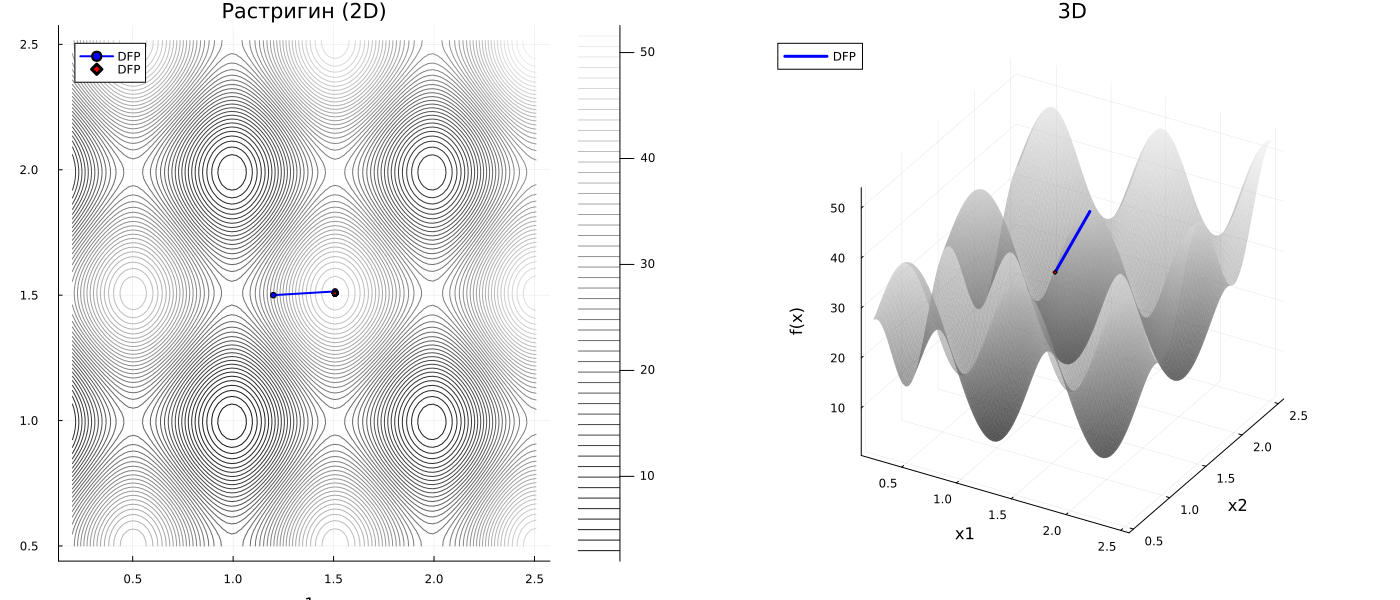

2-element Vector{Float64}:
 1.5076409734414924
 1.507640743532939

In [8]:
visualize_all_methods(rastrigin, "Растригин", [1.2, 1.5], 1.0)

ФУНКЦИЯ: Швефель | Старт: [400.0, 400.0]

DFP (Дэвидон-Флэтчер-Пауэл):
Итераций = 1 | Минимум = [420.968746, 420.968746] | f(x) = 2.54551e-5 | Время = 0.018 сек


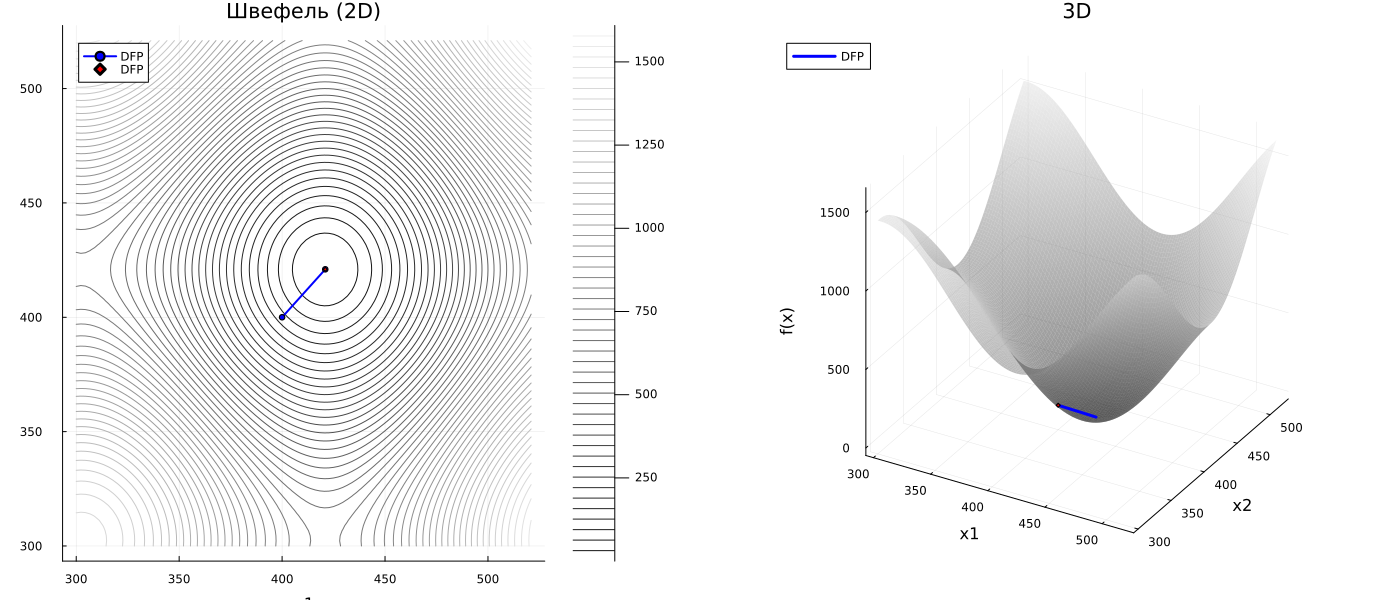

2-element Vector{Float64}:
 420.9687463581023
 420.9687463581023

In [9]:
visualize_all_methods(schwefel, "Швефель", [400.0, 400.0], 100.0)

In [12]:
function dfp_quadratic_test(Q, b, x0; max_iters=10, epsilon=1e-8)
    n = length(x0)
    H = Matrix{Float64}(I, n, n)        # H₀ = I
    sumA = zeros(n, n)
    sumB = zeros(n, n)

    f(x) = 0.5 * x' * Q * x - b' * x
    grad(x) = Q * x - b

    x = copy(x0)
    g = grad(x)

    for k in 1:max_iters
        if norm(g) < epsilon
            break
        end

        # Направление DFP
        p = -H * g

        # Точный одномерный поиск для квадратичной функции
        denom = p' * Q * p
        if abs(denom) < 1e-14
            break
        end
        alpha = -(g' * p) / denom

        x_new = x + alpha * p
        g_new = grad(x_new)

        s = x_new - x              # s_k
        y = g_new - g              # y_k = Q s_k

        sy = s' * y
        if abs(sy) > 1e-12 && sy > 0
            A = (s * s') / sy
            z = H * y
            yz = y' * z

            if abs(yz) > 1e-12
                B = (z * z') / yz
                H = H + A - B
                sumA .+= A
                sumB .+= B
            else
                H = H + A
                sumA .+= A
            end
        end

        x = x_new
        g = g_new
    end

    H_true_inv = inv(Q)
    E = Matrix{Float64}(I, n, n)

    println("Проверка для квадратичной функции:")
    println("‖ΣA - H^(-1)‖₂ = ", norm(sumA - H_true_inv))
    println("‖ΣB - E‖₂      = ", norm(sumB - E))

    println("Значение H^(-1):")
    println(H_true_inv)
    println("Значение Σ A^(i):")
    println(sumA)
    println("Значение Σ B^(i):")
    println(sumB)

    return sumA, sumB, H_true_inv, E
end

Q = [3.0 1.0; 1.0 2.0]
b = [1.0, 1.0]
x0 = [0.0, 0.0]
SA, SB, Hinv, E = dfp_quadratic_test(Q, b, x0)


Проверка для квадратичной функции:
‖ΣA - H^(-1)‖₂ = 3.744431865468923e-16
‖ΣB - E‖₂      = 2.7194799110210365e-16
Значение H^(-1):
[0.39999999999999997 -0.19999999999999998; -0.19999999999999998 0.6]
Значение Σ A^(i):
[0.3999999999999998 -0.19999999999999996; -0.19999999999999996 0.6000000000000003]
Значение Σ B^(i):
[1.0 1.1102230246251565e-16; 1.1102230246251565e-16 1.0000000000000002]


([0.3999999999999998 -0.19999999999999996; -0.19999999999999996 0.6000000000000003], [1.0 1.1102230246251565e-16; 1.1102230246251565e-16 1.0000000000000002], [0.39999999999999997 -0.19999999999999998; -0.19999999999999998 0.6], [1.0 0.0; 0.0 1.0])